In [1]:
# New York City Airbnb Open Data

# import all the required libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load the data

data = pd.read_csv("AB_NYC_2019.csv")
data


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2


In [2]:
# check data head

data.head

<bound method NDFrame.head of              id                                               name   host_id  \
0          2539                 Clean & quiet apt home by the park      2787   
1          2595                              Skylit Midtown Castle      2845   
2          3647                THE VILLAGE OF HARLEM....NEW YORK !      4632   
3          3831                    Cozy Entire Floor of Brownstone      4869   
4          5022   Entire Apt: Spacious Studio/Loft by central park      7192   
...         ...                                                ...       ...   
48890  36484665    Charming one bedroom - newly renovated rowhouse   8232441   
48891  36485057      Affordable room in Bushwick/East Williamsburg   6570630   
48892  36485431            Sunny Studio at Historical Neighborhood  23492952   
48893  36485609               43rd St. Time Square-cozy single bed  30985759   
48894  36487245  Trendy duplex in the very heart of Hell's Kitchen  68119814   

         

In [3]:
# check total columns infomation (data type) to adentify qualitative and quantitative data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

# We have 16 columns
## 5 Columns are objects and the others are numerical values

In [4]:
# check total null values per columns
data.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [5]:
# ckeck the column names that have numeric data type
numeric_column = data.select_dtypes(include='number').columns.tolist()
print("Numeric columns")
for i in numeric_column:
    print(i)

Numeric columns
id
host_id
latitude
longitude
price
minimum_nights
number_of_reviews
reviews_per_month
calculated_host_listings_count
availability_365


In [6]:
# Filter the Data-set to show only numeric columns for visualisation 
data_numeric = data.select_dtypes(include='number')
print(data_numeric.head())

     id  host_id  latitude  longitude  price  minimum_nights  \
0  2539     2787  40.64749  -73.97237    149               1   
1  2595     2845  40.75362  -73.98377    225               1   
2  3647     4632  40.80902  -73.94190    150               3   
3  3831     4869  40.68514  -73.95976     89               1   
4  5022     7192  40.79851  -73.94399     80              10   

   number_of_reviews  reviews_per_month  calculated_host_listings_count  \
0                  9               0.21                               6   
1                 45               0.38                               2   
2                  0                NaN                               1   
3                270               4.64                               1   
4                  9               0.10                               1   

   availability_365  
0               365  
1               355  
2               365  
3               194  
4                 0  


In [7]:
data_numeric.shape

(48895, 10)

## I droped non numeric values 

In [8]:


data_numeric.isna().sum()

id                                    0
host_id                               0
latitude                              0
longitude                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [9]:
# fill the missing values in "reviews_per_month" with the mean  

#Calculate the mean first

avg_reviews = data_numeric['reviews_per_month'].mean()

# filling the missing values
data_numeric['reviews_per_month'] = data_numeric['reviews_per_month'].fillna(avg_reviews)
# check
data_numeric.isna().sum()

id                                0
host_id                           0
latitude                          0
longitude                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

In [10]:
data_numeric.shape

(48895, 10)

# Visualise the Date set

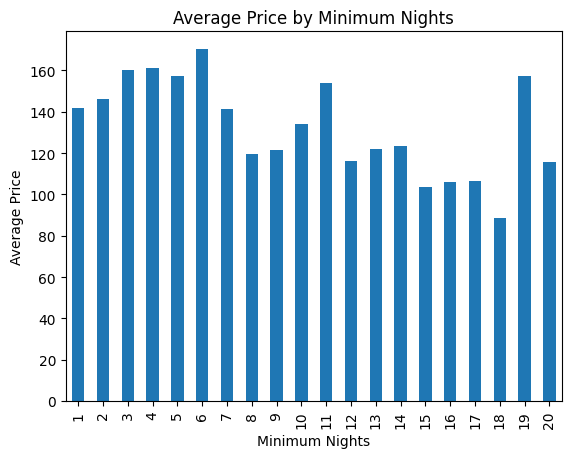

In [11]:
# Bar Chart: Average Price by Neighbourhood Group

avg_price = data_numeric.groupby('minimum_nights')['price'].mean().head(20)

plt.figure()
avg_price.plot(kind='bar')
plt.title('Average Price by Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Average Price')
plt.show()

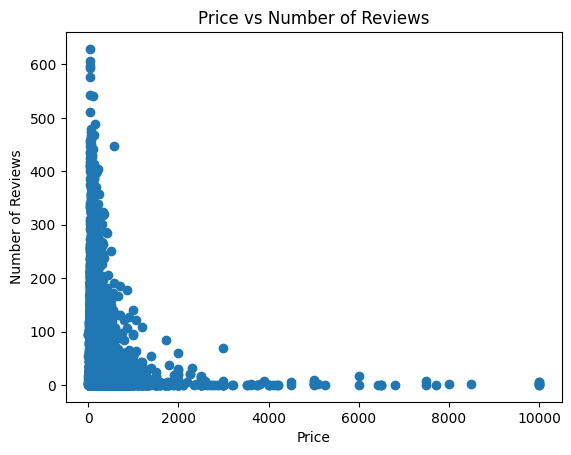

In [12]:
# Price vs Number of Reviews

plt.figure()
plt.scatter(data_numeric['price'], data_numeric['number_of_reviews'])
plt.title('Price vs Number of Reviews')
plt.xlabel('Price')
plt.ylabel('Number of Reviews')
plt.show()

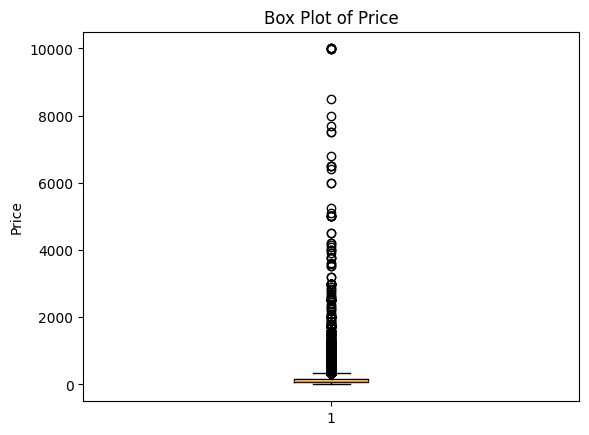

In [13]:
# Price distribution


plt.figure()
plt.boxplot(data_numeric['price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.show()

## From the Box plot: Min = 0, Max = 10000. This shows that the max value is an outlier 

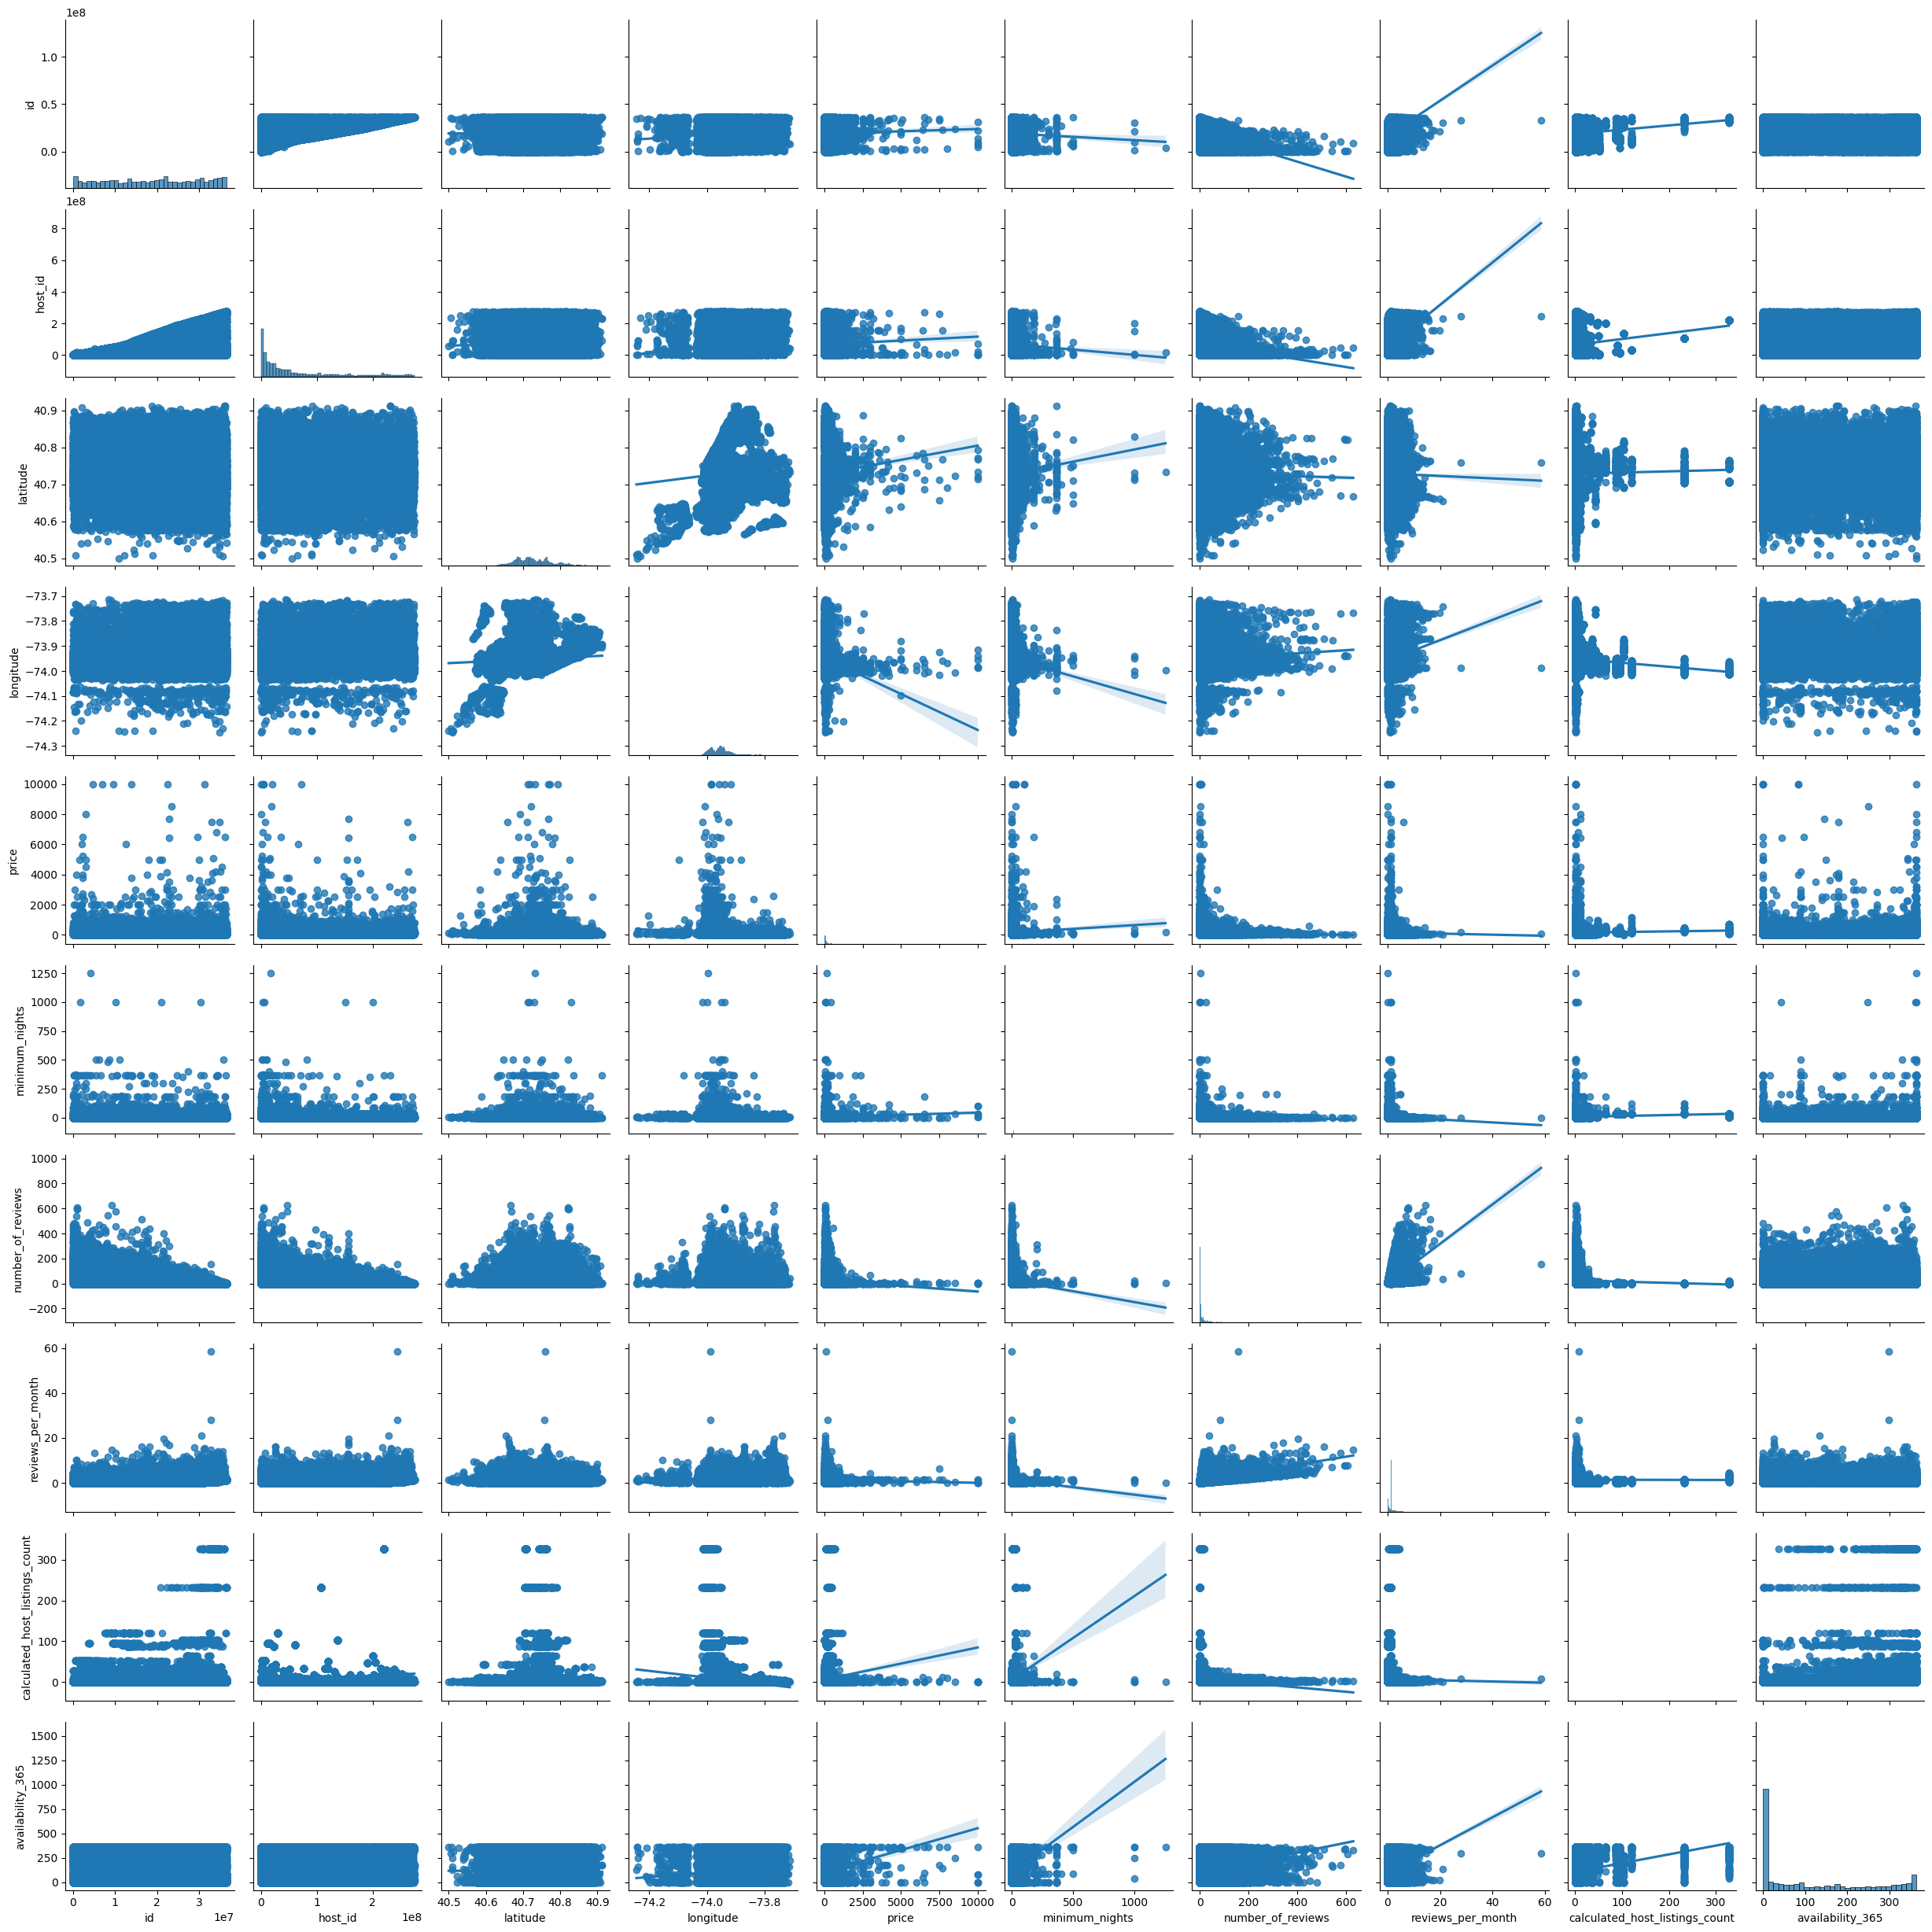

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(data_numeric, kind='reg')
plt.show()

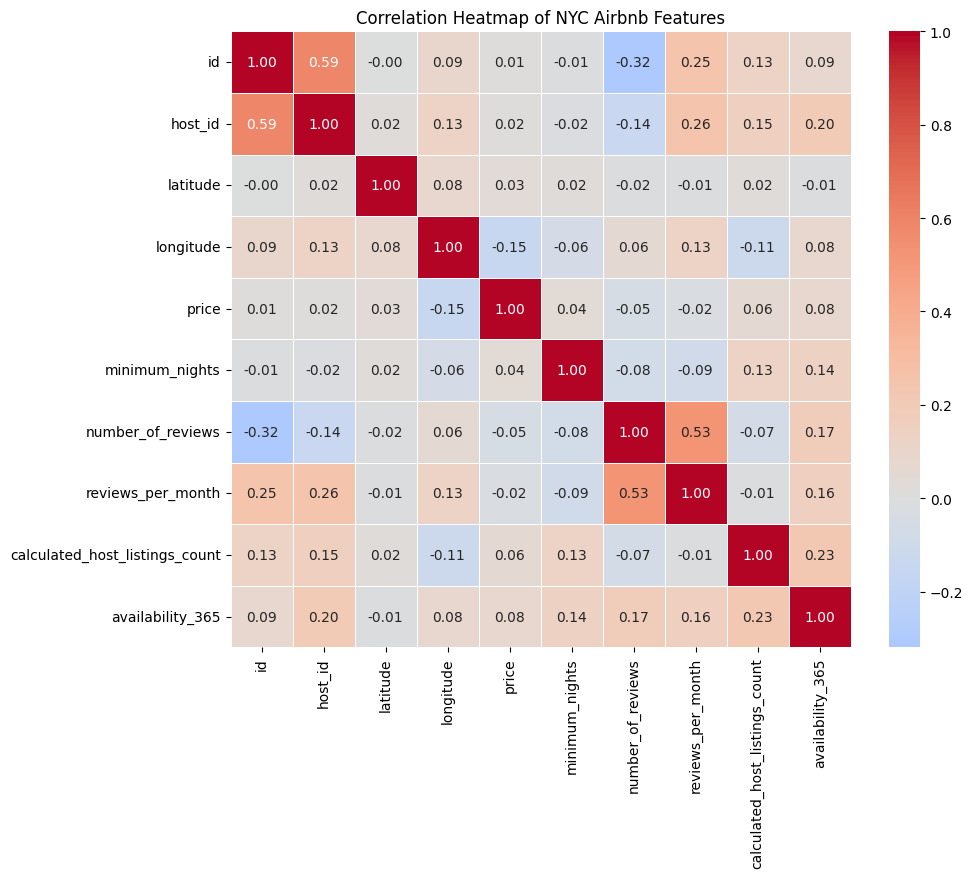

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Calculate the correlation matrix
corr_matrix = data_numeric.corr()

# Set up the figure size
plt.figure(figsize=(10, 8))

# Create the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          
    cmap='coolwarm',     
    fmt=".2f",           
    linewidths=0.5,      
    center=0             
)

plt.title('Correlation Heatmap of NYC Airbnb Features')
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of NYC Airbnb')

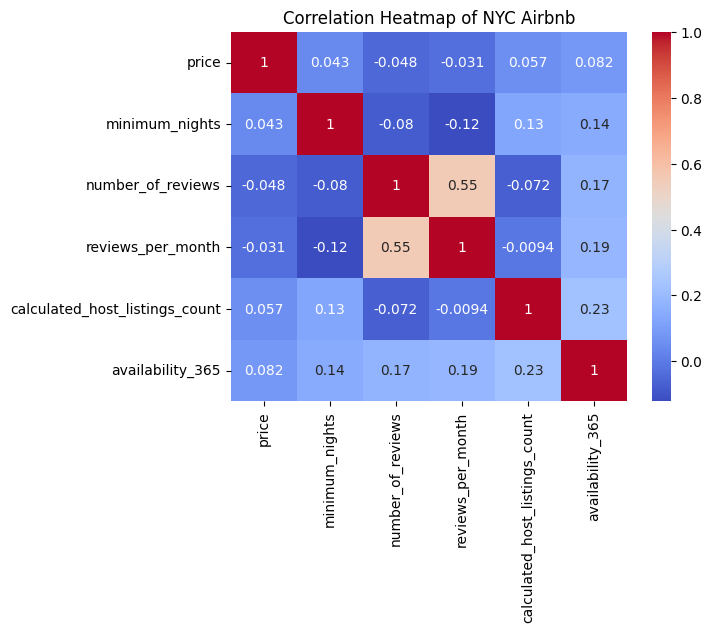

In [16]:
# Display only on the columns that we can use for analysis
refined_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
sns.heatmap(data[refined_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of NYC Airbnb')

## The heatmap reveals that while review activity is highly self-correlated, price is largely independent of other numeric factors like stay duration or availability, suggesting that a listing's cost is driven more by its location and property type than by the metrics shown in the matrix.

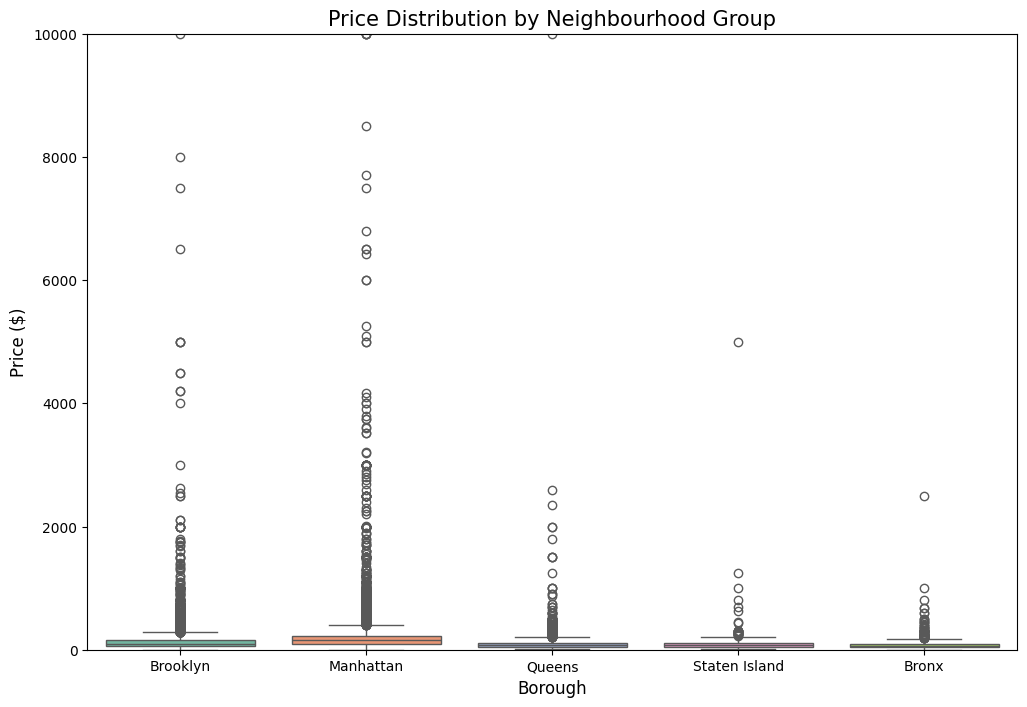

In [17]:

plt.figure(figsize=(12, 8))

sns.boxplot(
    x='neighbourhood_group', 
    y='price', 
    data=data, 
    hue='neighbourhood_group', 
    palette='Set2', 
    legend=False
)

plt.title('Price Distribution by Neighbourhood Group', fontsize=15)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

plt.ylim(0, 10000) 

plt.show()

## This shows the presence of outliers 

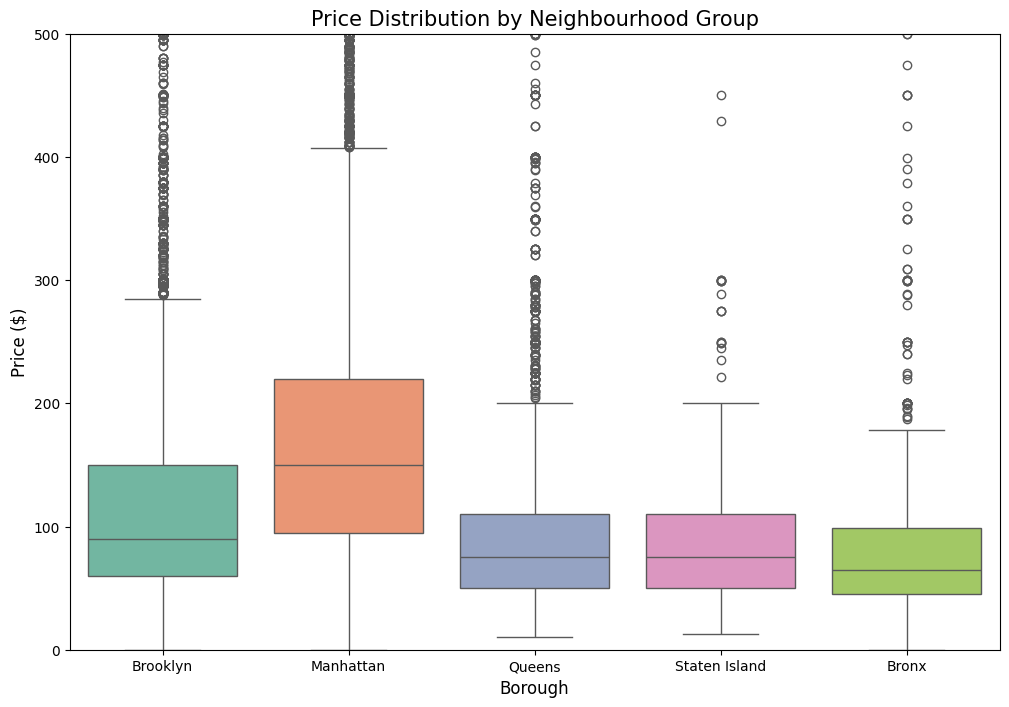

In [18]:

plt.figure(figsize=(12, 8))

sns.boxplot(
    x='neighbourhood_group', 
    y='price', 
    data=data, 
    hue='neighbourhood_group', 
    palette='Set2', 
    legend=False
)

plt.title('Price Distribution by Neighbourhood Group', fontsize=15)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)

# add a limit to clearly see the distribution 
plt.ylim(0, 500) 

plt.show()

### Looking at this box plot, it’s clear that Manhattan is the most expensive borough since its median line is the highest. You can also see that Manhattan and Brooklyn have a lot of 'outlier' dots at the top, which represent those super expensive luxury apartments. While most places across the city are more affordable, these outliers show that a few very high-priced listings really pull the average up.